# Issue #1: Define Congestion Metric and Forecasting Target

This notebook now uses the raw-derived processed dataset from Issue #4 (`modeling_dataset_2015_2019.csv`).

## 1) Setup and Data Loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start

repo_root = find_repo_root(Path.cwd())
modeling_path = repo_root / "data" / "processed" / "modeling_dataset_2015_2019.csv"

if not modeling_path.exists():
    raise FileNotFoundError(
        f"Missing {modeling_path}. Run notebooks/04_raw_preprocessing.ipynb first."
    )

df = pd.read_csv(modeling_path)
print(f"Loaded file: {modeling_path}")
print(f"Dataset shape: {df.shape}")


Loaded file: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/modeling_dataset_2015_2019.csv
Dataset shape: (5778, 12)


## 2) Data Understanding

In [2]:
print("Columns:", df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

required_cols = [
    "location_id", "date", "year", "month", "day_of_week", "is_weekend",
    "daily_total_volume", "peak_hour_volume", "peak_ratio", "congestion_target"
]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df["date"] = pd.to_datetime(df["date"], errors="coerce")


Columns: ['location_id', 'location_name', 'centreline_id', 'date', 'year', 'month', 'day_of_week', 'is_weekend', 'daily_total_volume', 'peak_hour_volume', 'peak_ratio', 'congestion_target']

Dtypes:
location_id               str
location_name             str
centreline_id           int64
date                      str
year                    int64
month                   int64
day_of_week             int64
is_weekend              int64
daily_total_volume      int64
peak_hour_volume        int64
peak_ratio            float64
congestion_target       int64
dtype: object

Missing values:
peak_ratio            1
location_id           0
location_name         0
centreline_id         0
date                  0
year                  0
month                 0
day_of_week           0
is_weekend            0
daily_total_volume    0
peak_hour_volume      0
congestion_target     0
dtype: int64


## 3) Target Validation and Cleaning

In [3]:
model_df = df.copy()
initial_rows = len(model_df)

rows_missing_target = model_df["congestion_target"].isna().sum()
model_df = model_df.dropna(subset=["congestion_target"]).copy()

rows_zero_target = (model_df["congestion_target"] == 0).sum()
model_df = model_df[model_df["congestion_target"] != 0].copy()

final_rows = len(model_df)

print("Cleaning summary:")
print(f"- Initial rows: {initial_rows:,}")
print(f"- Removed missing target: {rows_missing_target:,}")
print(f"- Removed zero target: {rows_zero_target:,}")
print(f"- Final rows: {final_rows:,}")

print("\nTarget summary:")
print(model_df["congestion_target"].describe())


Cleaning summary:
- Initial rows: 5,778
- Removed missing target: 0
- Removed zero target: 1
- Final rows: 5,777

Target summary:
count     5777.000000
mean     10877.726502
std       5834.647504
min          6.000000
25%       7237.000000
50%      10793.000000
75%      14580.000000
max      40994.000000
Name: congestion_target, dtype: float64


## 4) Congestion Level Labels (Quartiles)

In [4]:
level_labels = ["Low", "Medium", "High", "Severe"]
target_series = model_df["congestion_target"].astype("float64")
qcut_method_used = None

try:
    qcut_bins = pd.qcut(target_series, q=4, duplicates="drop")
    n_bins = qcut_bins.cat.categories.size

    if n_bins == 4:
        model_df["congestion_level"] = qcut_bins.cat.rename_categories(level_labels)
        qcut_method_used = "qcut (4 bins)"
    else:
        raise ValueError(f"qcut returned {n_bins} bins instead of 4")
except Exception as exc:
    percentile_edges = np.percentile(target_series, [0, 25, 50, 75, 100]).astype(float)
    for i in range(1, len(percentile_edges)):
        if percentile_edges[i] <= percentile_edges[i - 1]:
            percentile_edges[i] = percentile_edges[i - 1] + 1e-6

    model_df["congestion_level"] = pd.cut(
        target_series,
        bins=[float(x) for x in percentile_edges.tolist()],
        labels=level_labels,
        include_lowest=True,
        right=True,
    )
    qcut_method_used = f"percentile fallback ({exc})"

if model_df["congestion_level"].isna().any():
    model_df["congestion_level"] = pd.qcut(
        target_series.rank(method="first"),
        q=4,
        labels=level_labels,
    )
    qcut_method_used += " + rank-based guardrail"

model_df["congestion_level"] = pd.Categorical(
    model_df["congestion_level"], categories=level_labels, ordered=True
)

print("Congestion level method:", qcut_method_used)
print(model_df["congestion_level"].value_counts().reindex(level_labels))


Congestion level method: qcut (4 bins)
congestion_level
Low       1445
Medium    1445
High      1443
Severe    1444
Name: count, dtype: int64


## 5) Visual Checks

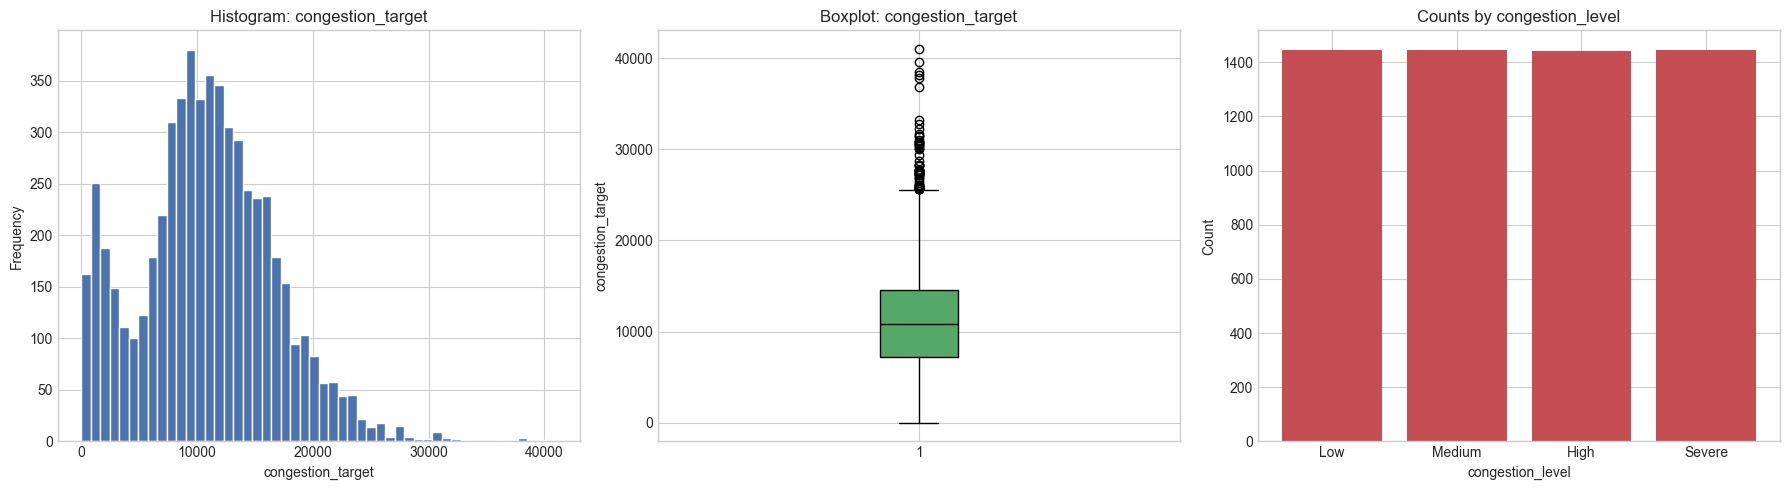

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(model_df["congestion_target"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Histogram: congestion_target")
axes[0].set_xlabel("congestion_target")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(
    model_df["congestion_target"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#55A868"),
    medianprops=dict(color="black"),
)
axes[1].set_title("Boxplot: congestion_target")
axes[1].set_ylabel("congestion_target")

level_counts = model_df["congestion_level"].value_counts().reindex(level_labels)
axes[2].bar(level_counts.index.astype(str), level_counts.values, color="#C44E52")
axes[2].set_title("Counts by congestion_level")
axes[2].set_xlabel("congestion_level")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()


## Outputs

- Input used: `data/processed/modeling_dataset_2015_2019.csv`
- In-memory output: `model_df` with `congestion_level` quartile labels